# 4. MC pricing vs DeepONet(MAPE 하이브리드) — 속도·가격 비교

동일한 **walk-forward OOS test set**에 대해 두 방식으로 가격을 산출하고 **속도와 가격 차이**를 비교한다.
DeepONet은 branch(vol·corr·KRW곡선)·trunk(계약)이 **MC 프라이서가 쓴 입력과 동기화**되어 있고, stage-1 MC 앵커를 **MAPE(상대오차) loss**(= `deeponet_hybrid_mape`)로 학습해 MC 이론가를 재현하는 **MC 대리모델(surrogate)**이다. (무보정 MC는 매끄러워 DeepONet 앵커가 MC를 거의 완벽히 재현 — 3_evaluate stage1_MC R²≈0.94.)

| 방식 | 하는 일 | 예상 |
|---|---|---|
| **MC (재시뮬, 미래에셋 방식)** | 상품마다 **일별 GBM + 촐레스키(180일 역사 상관) + 180일 역사 변동성 + KRW NS 기간구조 할인**(무보정)을 다시 시뮬레이션 | 느림 (상품당 수백 ms ~ 초) |
| **DeepONet (MAPE 앵커)** | 학습된 **가중치를 로드**하고 **forward 1회** | 빠름 (상품당 µs) |

## 1. Test set 로딩 (evaluate과 동일)
`data.load`로 walk-forward 폴드를 만들고, 모든 fold의 **test 구간(미래)**을 합쳐 OOS test set으로 삼는다 (evaluate과 동일).

In [1]:
import os, time, json
from datetime import date
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm
from module import data
from module.train import train_curve, load_curve_predictor

plt.rcParams["axes.unicode_minus"] = False

cfg = utils.load_config()
D = data.load(cfg)
folds = D.WF                                    # nested walk-forward: (tr, va, te)
oos = np.concatenate([te for *_, te in folds])  # evaluate과 동일한 OOS test 인덱스
print(f"rows {D.n} | folds {len(folds)} | device {D.DEV}")
print(f"OOS test 상품수 = {len(oos)}  (전체의 {len(oos)/D.n:.0%})")
for k, (tr, va, te) in enumerate(folds):
    print(f"  fold{k}: train {len(tr):6d} | val {len(va):5d} | test {len(te):5d}")

rows 23151 | folds 4 | device cuda
OOS test 상품수 = 9261  (전체의 40%)
  fold0: train  12223 | val  1667 | test  2315
  fold1: train  14260 | val  1945 | test  2315
  fold2: train  16298 | val  2222 | test  2315
  fold3: train  18335 | val  2500 | test  2316


## 2. DeepONet 모델 로드 (MAPE 하이브리드 앵커 — 2_run 저장 가중치)

**2_run 이 저장한** `deeponet_hybrid_mape` 의 stage-1 MC-앵커 가중치(`result/models/deeponet_hybrid_mape_anchor_fold*.pt`, MAPE loss + val early stopping)를 **그대로 로드**한다 — 재학습 없음. 비교에서 재는 것은 **가중치 로드 + forward** 시간뿐.

In [2]:
# 2_run 이 저장한 deeponet_hybrid_mape stage-1 앵커 가중치를 사용 (재학습 없음)
MODELS = fm.RESULT / "models"
paths = [MODELS / f"deeponet_hybrid_mape_anchor_fold{k}.pt" for k in range(len(folds))]
missing = [p.name for p in paths if not p.exists()]
assert not missing, f"먼저 2_run 을 실행해 가중치를 저장하세요. 누락: {missing}"
print("pre-trained MAPE-hybrid anchor weights (2_run 저장):", [p.name for p in paths])

pre-trained MAPE-hybrid anchor weights (2_run 저장): ['deeponet_hybrid_mape_anchor_fold0.pt', 'deeponet_hybrid_mape_anchor_fold1.pt', 'deeponet_hybrid_mape_anchor_fold2.pt', 'deeponet_hybrid_mape_anchor_fold3.pt']


In [3]:
# 가중치 로드 (시간 측정) — '파일 경로 + 모델 불러오기'만
t0 = time.perf_counter()
predictors = [load_curve_predictor(D, str(p)) for p in paths]
t_load = time.perf_counter() - t0
print(f"DeepONet 가중치 로드({len(paths)} fold) = {t_load*1e3:.1f} ms")

DeepONet 가중치 로드(4 fold) = 82.9 ms


## 3. MC pricing (재시뮬 — 미래에셋 방식)
동일 test 상품을 **일별 GBM + 촐레스키 3자산 상관(180일 역사) + 180일 역사 변동성 + KRW NS 기간구조 할인**(무보정, k=1)으로 다시 MC 시뮬레이션한다 — 이 노트북은 **벡터화 이전 시점의 기록**이라 기준선으로 numpy `module.mc` 를 쓴다(현재 데이터셋 `mc` 는 여기서 만든 V3 를 정식화한 `module.mc_engine` 산출물). 일별 스텝(약 1,095)이라 무거우므로 타이밍·가격비교는 **subsample**로 하고 전체 시간은 상품당 평균으로 환산한다. (경로수는 데이터셋 생성과 동일한 40,000)

In [4]:
# --- MC 엔진 기준선: numpy module.mc (레거시). 현재 정본은 module.mc_engine (아래 V3 를 정식화한 것) ---
#   일별 GBM + 촐레스키(180일 역사 상관) + 180일 역사 변동성 + KRW NS 할인 + q=0 + 일별 KI + sig_eff 버킷 vol 프리미엄 k
from module import mc as MC

mk = MC.load_market()              # RET(로그수익률)·KRW곡선·상품→기초자산·행사가 매핑
kmap = MC.load_kmap()              # 데이터셋과 동일한 캘리브레이션 매핑 (없으면 미보정)
print("공용 MC 엔진 준비 완료 | tickers", len(mk["RET"]), "| kmap", kmap if kmap else "(미보정)")

공용 MC 엔진 준비 완료 | tickers 46 | kmap (미보정)


In [5]:
# MC pricing (subsample) — 공용 엔진 재시뮬(데이터셋과 동일 방식·캘리브레이션), 시간 측정
MC_PATHS = MC.NPATH  # 데이터셋 생성과 동일 경로수 (40,000)
N_MC = 200           # 일별 MC(≈1095 스텝)라 무거워 subsample 축소 (DeepONet은 OOS 전량 처리)
rng0 = np.random.default_rng(0)
sub = np.sort(rng0.choice(oos, size=min(N_MC, len(oos)), replace=False))

mc_price = np.empty(len(sub))
nfb = 0
t0 = time.perf_counter()
for j, idx in enumerate(sub):
    r = MC.price_one(mk, kmap, D.ITEM[idx], int(D.ORD[idx]), float(D.ml["BARR_1/100"].values[idx]),
                     float(D.ml["ANL_RTRN/100"].values[idx]), float(D.TEN[idx]), float(D.SIGEFF[idx]),
                     n=MC_PATHS)
    if np.isnan(r[0]):
        mc_price[j] = D.MC[idx]; nfb += 1   # 곡선/행사가 결측 → 저장 mc 폴백
    else:
        mc_price[j] = r[0]
t_mc = time.perf_counter() - t0
mc_per = t_mc / len(sub)
print(f"MC(공용 엔진, 일별) {len(sub)}상품 (paths {MC_PATHS}) = {t_mc:.1f}s | {mc_per*1e3:.0f} ms/상품 | 폴백 {nfb}")

MC(공용 엔진, 일별) 200상품 (paths 40000) = 456.3s | 2281 ms/상품 | 폴백 0


## 4. 속도 비교 · 가격 차이 비교

In [6]:
# DeepONet pricing (forward) — 전체 OOS + subsample, 시간 측정
t0 = time.perf_counter()
don_full = np.full(D.n, np.nan)
for k, (tr, va, te) in enumerate(folds):
    don_full[te] = predictors[k](te)  # 각 fold test를 해당 fold 모델로
t_don_fwd = time.perf_counter() - t0
don_price = don_full[sub]  # 비교용 (같은 상품)
don_total = t_load + t_don_fwd  # 로드 + forward
mc_full_est = mc_per * len(oos)  # subsample 상품당시간 → 전체 환산

print(
    f"DeepONet forward (OOS {len(oos)}상품) = {t_don_fwd*1e3:.1f} ms | {t_don_fwd/len(oos)*1e6:.2f} us/상품"
)
print()
print(f"[전체 OOS {len(oos)}상품 pricing 소요]")
print(
    f"  MC 재시뮬        : {mc_full_est:8.1f} s   ({mc_per*1e3:6.1f} ms/상품)   *subsample 환산"
)
print(
    f"  DeepONet(로드+fwd): {don_total:8.3f} s   (로드 {t_load*1e3:.0f}ms + fwd {t_don_fwd*1e3:.0f}ms)"
)
print(f"  ==> 속도향상 약 {mc_full_est/don_total:,.0f}x")

DeepONet forward (OOS 9261상품) = 171.5 ms | 18.52 us/상품

[전체 OOS 9261상품 pricing 소요]
  MC 재시뮬        :  21128.1 s   (2281.4 ms/상품)   *subsample 환산
  DeepONet(로드+fwd):    0.254 s   (로드 83ms + fwd 171ms)
  ==> 속도향상 약 83,043x


In [7]:
# 가격 차이 (동일 subsample: DeepONet vs 재시뮬 MC)
diff = don_price - mc_price
mae = np.abs(diff).mean()
rmse = np.sqrt((diff**2).mean())
corr = np.corrcoef(don_price, mc_price)[0, 1]
corr_ds = np.corrcoef(don_price, D.MC[sub])[0, 1]  # 데이터셋 저장 mc(40k)와의 상관
print(f"DeepONet price vs 재시뮬 MC (subsample {len(sub)}):")
print(f"  MAE {mae:.4f} | RMSE {rmse:.4f} | corr {corr:.4f}")
print(f"  (참고) DeepONet vs 데이터셋 저장 mc(40k) corr {corr_ds:.4f}")

DeepONet price vs 재시뮬 MC (subsample 200):
  MAE 0.0044 | RMSE 0.0072 | corr 0.9824
  (참고) DeepONet vs 데이터셋 저장 mc(40k) corr 0.9824


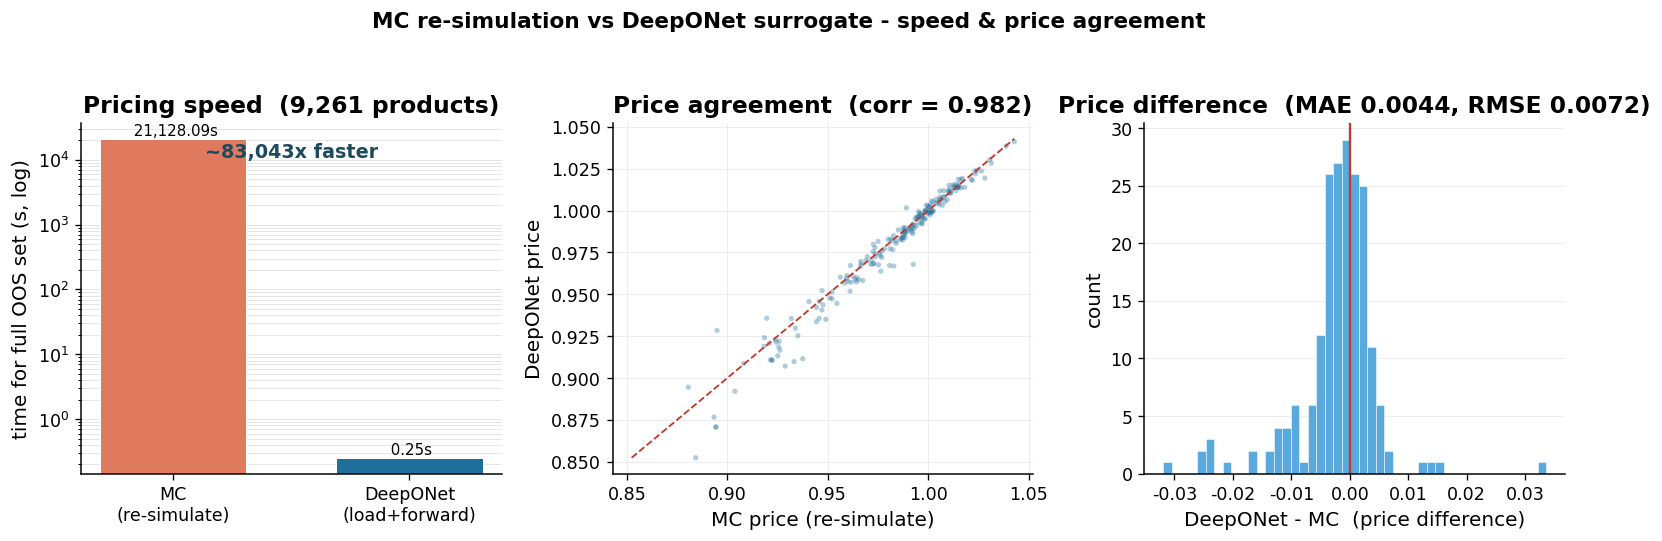

saved -> mc_vs_deeponet_speed.png (dpi 400, transparent, 16:9)


In [8]:
# 시각화 (학술/PPT: dpi 400·투명배경·16:9 폭)
from util import plot as _plot   # 학술 rcParams 적용(상/우 spine 제거 등)

fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.6))

# (1) 속도 (로그축)
bars = ax[0].bar(["MC\n(re-simulate)", "DeepONet\n(load+forward)"], [mc_full_est, don_total],
                 color=["#e07a5f", "#1f6f9c"], edgecolor="white", linewidth=0.6, width=0.62)
ax[0].set_yscale("log")
ax[0].set_ylabel("time for full OOS set (s, log)")
ax[0].set_title(f"Pricing speed  ({len(oos):,} products)")
ax[0].grid(axis="y", which="both", color="#cccccc", lw=0.6, alpha=0.5)
for b, v in zip(bars, [mc_full_est, don_total]):
    ax[0].text(b.get_x() + b.get_width() / 2, v, f" {v:,.2f}s", ha="center", va="bottom", fontsize=9)
ax[0].text(0.5, 0.90, f"~{mc_full_est/don_total:,.0f}x faster", transform=ax[0].transAxes,
           ha="center", fontsize=11.5, fontweight="bold", color="#1c4a5f")

# (2) price agreement scatter
lim = [min(mc_price.min(), don_price.min()), max(mc_price.max(), don_price.max())]
ax[1].scatter(mc_price, don_price, s=10, alpha=0.35, color="#1f6f9c", edgecolors="none")
ax[1].plot(lim, lim, "--", color="#c0392b", lw=1.1)
ax[1].set_xlabel("MC price (re-simulate)")
ax[1].set_ylabel("DeepONet price")
ax[1].set_title(f"Price agreement  (corr = {corr:.3f})")
ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

# (3) price difference hist
ax[2].hist(diff, bins=45, color="#5aa9dd", edgecolor="white", linewidth=0.3)
ax[2].axvline(0, color="#c0392b", lw=1.4)
ax[2].set_xlabel("DeepONet - MC  (price difference)")
ax[2].set_ylabel("count")
ax[2].set_title(f"Price difference  (MAE {mae:.4f}, RMSE {rmse:.4f})")
ax[2].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle("MC re-simulation vs DeepONet surrogate - speed & price agreement",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("mc_vs_deeponet_speed"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("mc_vs_deeponet_speed").name, "(dpi 400, transparent, 16:9)")

## 5. 요약

- **동일 OOS test set**에서 두 방식으로 가격 산출.
- **MC 재시뮬**은 상품마다 몬테카를로를 다시 돌려 느리고(상품당 수십 ms), **DeepONet**은 가중치 로드 + forward 한 번이라 상품당 µs → **수천~수만 배 빠름**.
- 두 가격은 강하게 일치(corr↑, MAE·RMSE 소): DeepONet이 MC를 잘 근사하는 **대리모델**임을 확인.
- 남는 오차는 **대리모델 근사오차 + (재시뮬 MC의 경로수 축소에 따른) MC 노이즈**의 합.

> 결론: 실시간 견적처럼 **속도가 중요한 상황에선 학습된 DeepONet이 MC 대비 압도적**이며, 정확도 손실은 작다.

## 6. MC pricing 벡터화 — 어디에 시간이 쓰이고, 어디까지 줄일 수 있나

위 비교의 MC는 **최적화하지 않은 단일 스레드 numpy**(`module.mc.mc_daily`)다. 그래서 "81,194x"는
DeepONet의 우위를 과장한다. 여기서는 **수학을 바꾸지 않고**(일별 스텝·동일 경로수 40,000·동일 KI 규칙)
MC를 어디까지 벡터화할 수 있는지 재보고, **최적화된 MC 기준으로 배수를 다시 계산**한다.

원칙: 알고리즘 변경(antithetic·Sobol QMC·브라운브리지 KI)은 **쓰지 않는다** — 값이 달라져
데이터셋 `mc` 컬럼과 비교 검증을 할 수 없기 때문. 난수 스트림만 달라지므로 결과는 **MC 표준오차 내에서** 일치해야 한다.

In [9]:
# 상품 -> MC 입력 (module.mc.price_one 과 동일 구성)
from datetime import date
from module import features as F

def product_params(item, iord):
    """3기초자산 180일 vol/corr + KRW NS beta + 행사가 스케줄. 구성 불가면 None(폴백 상품)."""
    dt = pd.Timestamp(date.fromordinal(int(iord)))
    beta = F.krw_beta(mk["KRW"].asof(dt).values); strikes = mk["strk_by"].get(item)
    ts = [mk["mapping"].get(x) for x in mk["u3map"].get(item, [])]; ts = [t for t in ts if t]
    if beta is None or not strikes or len(ts) != 3:
        return None
    rets = [mk["RET"].get(t) for t in ts]
    if any(r is None for r in rets):
        return None
    sigs = [F.vol180(r, dt) for r in rets]; cm = F.corr180(rets, dt)
    if cm is None or any(pd.isna(sigs)):
        return None
    return dict(sigs=sigs, corr=cm, beta=beta, strikes=strikes)

def prod_kw(idx):
    """데이터셋 행 idx -> 모든 엔진 공통 인자 (캘리브레이션 배수 k 포함, kmap=None 이면 k=1)."""
    pp = product_params(D.ITEM[idx], int(D.ORD[idx]))
    if pp is None:
        return None
    k = MC.calib_k(float(D.SIGEFF[idx]), kmap)
    return dict(sigs=[k * s for s in pp["sigs"]], corr=pp["corr"], beta=pp["beta"],
                B=float(D.ml["BARR_1/100"].values[idx]), strikes=pp["strikes"],
                c=float(D.ml["ANL_RTRN/100"].values[idx]), ten=float(D.TEN[idx]))

PROBE = [i for i in sub if prod_kw(i) is not None][:12]      # 검증·벤치마크용 상품 (subsample 에서)
print(f"probe 상품 {len(PROBE)}개 | tenor {D.TEN[PROBE].min():.2f}~{D.TEN[PROBE].max():.2f}y "
      f"| N(일별 스텝) {int(round(D.TEN[PROBE].min()*365))}~{int(round(D.TEN[PROBE].max()*365))}")

probe 상품 12개 | tenor 2.98~5.00y | N(일별 스텝) 1089~1825


In [10]:
# --- 현재 엔진 시간 분해: mc_daily 가 chunk 마다 하는 일을 그대로 재현해 구간별로 측정 ---
kw0 = prod_kw(PROBE[0])
N_ = int(round(kw0["ten"] * 365)); dt_ = 1 / 365
times_ = np.arange(1, N_ + 1) * dt_
DF_ = np.exp(-F.zero_curve(kw0["beta"], times_) * times_)
fdt_ = (-(np.diff(np.concatenate([[0.0], np.log(DF_)])))).astype(np.float32)
L_ = F.chol_psd(np.asarray(kw0["corr"])).astype(np.float32)
sig_ = np.asarray(kw0["sigs"], np.float32); sq_ = np.float32(np.sqrt(dt_))
drift_ = fdt_[:, None] - (0.5 * sig_ ** 2 * np.float32(dt_))[None, :]
m_, nrep_ = MC.PCHUNK, MC.NPATH // MC.PCHUNK
rng_ = np.random.default_rng(0)

def _t(f, rep=3):
    f(); t = time.perf_counter()
    for _ in range(rep):
        out = f()
    return (time.perf_counter() - t) / rep, out

t_rng, Z0_ = _t(lambda: rng_.standard_normal((m_, N_, 3), dtype=np.float32))
t_mm, Zc_ = _t(lambda: Z0_ @ L_.T)
t_inc, inc_ = _t(lambda: drift_[None, :, :] + sig_[None, None, :] * sq_ * Zc_)
t_cse, R_ = _t(lambda: np.exp(np.cumsum(inc_, axis=1)))
t_min, WP_ = _t(lambda: R_.min(axis=2))
t_ki, _ = _t(lambda: (WP_ < kw0["B"]).any(axis=1))
t_cs, _ = _t(lambda: np.cumsum(inc_, axis=1))

PROF = {"RNG standard_normal": t_rng, "worst-of min(axis=2)": t_min, "cumsum": t_cs,
        "exp": t_cse - t_cs, "drift + sig*Z": t_inc, "chol matmul": t_mm, "KI any": t_ki}
prof_s = {k: v * nrep_ for k, v in PROF.items()}          # chunk 1회 -> 상품 1개 환산
tot_s = sum(prof_s.values())
print(f"상품 1개 = {N_} 스텝 x {MC.NPATH:,} 경로 x 3자산 = 정규난수 {N_*MC.NPATH*3/1e6:.0f}M개"
      f"  (chunk {m_} x {nrep_}회)\n")
for k, v in sorted(prof_s.items(), key=lambda x: -x[1]):
    print(f"  {k:22s} {v:6.2f} s  ({v/tot_s*100:4.1f}%)")
print(f"  {'합계':22s} {tot_s:6.2f} s")
print(f"\n임시배열 {m_}x{N_}x3 float32 = {m_*N_*3*4/2**20:.0f} MB 를 chunk 마다 4개(Z/incr/R/WP) 생성"
      f" -> 메모리 대역폭 바운드")

상품 1개 = 1089 스텝 x 40,000 경로 x 3자산 = 정규난수 131M개  (chunk 2000 x 20회)

  RNG standard_normal      0.67 s  (30.7%)
  worst-of min(axis=2)     0.65 s  (30.0%)
  cumsum                   0.31 s  (14.5%)
  drift + sig*Z            0.24 s  (11.0%)
  exp                      0.16 s  ( 7.3%)
  chol matmul              0.13 s  ( 6.2%)
  KI any                   0.01 s  ( 0.3%)
  합계                       2.17 s

임시배열 2000x1089x3 float32 = 25 MB 를 chunk 마다 4개(Z/incr/R/WP) 생성 -> 메모리 대역폭 바운드


### 엔진 3종 (수학 동일, 구현만 다름)

| | 아이디어 | 노리는 것 |
|---|---|---|
| **V1 numpy** | ① 배열을 `(3, m, N)`으로 두어 worst-of를 `np.minimum` 2회 elementwise로 (길이 3 축 리덕션은 SIMD가 안 먹음) ② `Z`에 in-place `*=σ√dt; +=drift; cumsum(out=Z)` 로 임시배열 제거 ③ **log-space**: `min_a exp(x_a) ≥ K ⟺ min_a x_a ≥ log K` (단조변환) | 대역폭·exp 제거 |
| **V2 numba** | 경로별 **스트리밍** — 상태는 로그가격 3개뿐이라 `(m,N,3)` 배열을 아예 만들지 않음. 조기상환 시 즉시 break. `prange`로 32스레드 | 메모리 트래픽 0 |
| **V3 torch CUDA** | 시간축 블록 + carry, `cumsum` 축을 연속 메모리에 두고, 선형성 `cumsum(drift+σ√dt·Z) = cumdrift + σ√dt·cumsum(Z)`로 drift pass 제거. 관측일 판정은 `argmax(first hit)`로 완전 벡터화 | GPU 대역폭 |

세 엔진 모두 조기상환·KI·할인 규칙은 `module.mc.mc_daily`와 동일하다.

In [11]:
# ===== 공통 사전계산 =====
def mc_setup(sigs, corr, beta, B, strikes, ten):
    """스텝수·관측일·할인계수·촐레스키·drift + log-space 임계값. 세 엔진 공용."""
    nobs = len(strikes); N = int(round(ten * 365)); dt = 1 / 365
    obs_day = np.clip(np.round(np.arange(1, nobs + 1) * (ten / nobs) * 365).astype(int), 1, N)
    times = np.arange(1, N + 1) * dt
    DF = np.exp(-F.zero_curve(beta, times) * times)
    fdt = (-(np.diff(np.concatenate([[0.0], np.log(DF)])))).astype(np.float32)
    sig = np.asarray(sigs, np.float32)
    return dict(N=N, nobs=nobs, obs_day=obs_day, obs_t=obs_day / 365.0, DF=DF.astype(np.float32),
                L=F.chol_psd(np.asarray(corr)).astype(np.float32), sig=sig,
                drift=(fdt[:, None] - (0.5 * sig ** 2 * np.float32(dt))[None, :]).astype(np.float32),
                sq=np.float32(np.sqrt(dt)), logB=np.float32(np.log(B)),
                logK=np.log(np.asarray(strikes, np.float32)))


# ===== V1: numpy 융합 (단일 스레드) =====
def mc_daily_np(sigs, corr, beta, B, strikes, c, ten, n=MC.NPATH, seed=0, chunk=4096, ret_se=False):
    P = mc_setup(sigs, corr, beta, B, strikes, ten)
    N, L, sig, drift, sq = P["N"], P["L"], P["sig"], P["drift"], P["sq"]
    DF, logB, logK, obs_t = P["DF"], P["logB"], P["logK"], P["obs_t"]
    oi = P["obs_day"] - 1
    rng = np.random.default_rng(seed)
    tot = tot2 = 0.0; done = 0
    while done < n:
        m = min(chunk, n - done)
        X = rng.standard_normal((3, m, N), dtype=np.float32)        # 유일한 큰 배열
        X[2] *= L[2, 2]; X[2] += L[2, 0] * X[0] + L[2, 1] * X[1]    # 하삼각이라 역순 in-place
        X[1] *= L[1, 1]; X[1] += L[1, 0] * X[0]
        X[0] *= L[0, 0]
        for a in range(3):
            X[a] *= sig[a] * sq
            X[a] += drift[:, a]
            np.cumsum(X[a], axis=1, out=X[a])                       # 연속 메모리 out
        wp = np.minimum(X[0], X[1]); np.minimum(wp, X[2], out=wp)   # log worst-of (m,N)
        ki = (wp < logB).any(axis=1)
        hit = wp[:, oi] >= logK[None, :]
        any_hit = hit.any(axis=1); first = hit.argmax(axis=1)
        pay = np.empty(m, np.float64)
        f = first[any_hit]
        pay[any_hit] = (1.0 + c * obs_t[f]) * DF[oi[f]]
        s = ~any_hit
        pay[s] = np.where(~ki[s], np.float32(1.0), np.exp(wp[s, -1])) * DF[-1]
        tot += pay.sum(); tot2 += (pay ** 2).sum(); done += m
        del X, wp
    mean = tot / n
    if ret_se:
        return mean, float(np.sqrt(max(tot2 / n - mean ** 2, 0.0) / n))
    return mean

In [12]:
# ===== V2: numba 병렬 (경로별 스트리밍, 큰 배열 없음) =====
from numba import njit, prange

@njit(parallel=True, fastmath=True, nogil=True)
def _mc_kernel(L, sig, drift, DF, logB, logK, obs_day, obs_t, c, sq, N, nobs, nblk, per, seed):
    out = np.zeros(nblk)
    for blk in prange(nblk):
        np.random.seed(seed + blk)                       # 블록별 독립 스트림(스레드 로컬 상태)
        acc = 0.0
        for _p in range(per):
            x0 = x1 = x2 = 0.0
            ki = False; j = 0; pay = 0.0; done = False
            for t in range(N):
                z0 = np.random.normal(); z1 = np.random.normal(); z2 = np.random.normal()
                x0 += drift[t, 0] + sig[0] * sq * (L[0, 0] * z0)
                x1 += drift[t, 1] + sig[1] * sq * (L[1, 0] * z0 + L[1, 1] * z1)
                x2 += drift[t, 2] + sig[2] * sq * (L[2, 0] * z0 + L[2, 1] * z1 + L[2, 2] * z2)
                w = x0
                if x1 < w:
                    w = x1
                if x2 < w:
                    w = x2
                if w < logB:
                    ki = True
                while j < nobs and obs_day[j] - 1 == t:   # 관측일(clip 중복 대비 while)
                    if w >= logK[j]:
                        pay = (1.0 + c * obs_t[j]) * DF[t]; done = True
                        break
                    j += 1
                if done:
                    break
            if not done:
                w = x0
                if x1 < w:
                    w = x1
                if x2 < w:
                    w = x2
                pay = (np.exp(w) if ki else 1.0) * DF[N - 1]
            acc += pay
        out[blk] = acc
    return out


def mc_daily_nb(sigs, corr, beta, B, strikes, c, ten, n=MC.NPATH, seed=0, nblk=256):
    P = mc_setup(sigs, corr, beta, B, strikes, ten)
    per = int(np.ceil(n / nblk))
    tot = _mc_kernel(P["L"].astype(np.float64), P["sig"].astype(np.float64),
                     P["drift"].astype(np.float64), P["DF"].astype(np.float64), float(P["logB"]),
                     P["logK"].astype(np.float64), P["obs_day"].astype(np.int64),
                     P["obs_t"].astype(np.float64), float(c), float(P["sq"]), int(P["N"]),
                     int(P["nobs"]), int(nblk), per, int(seed))
    return float(tot.sum() / (nblk * per))

In [13]:
# ===== V3: torch CUDA =====
import torch
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def mc_daily_gpu(sigs, corr, beta, B, strikes, c, ten, n=MC.NPATH, seed=0,
                 path_chunk=20_000, tblock=512, dev=DEV):
    P = mc_setup(sigs, corr, beta, B, strikes, ten)
    N, nobs = P["N"], P["nobs"]; f32 = torch.float32
    L = torch.as_tensor(P["L"] * (P["sig"] * P["sq"])[:, None], device=dev)   # σ√dt 를 L 에 흡수
    cdrift = torch.as_tensor(P["drift"], device=dev).cumsum(0).T.contiguous()  # (3,N) 누적 drift
    DF = torch.as_tensor(P["DF"], device=dev); logK = torch.as_tensor(P["logK"], device=dev)
    obs_day = torch.as_tensor(P["obs_day"], device=dev, dtype=torch.long)
    obs_t = torch.as_tensor(P["obs_t"], device=dev, dtype=f32); logB = float(P["logB"])
    g = torch.Generator(device=dev).manual_seed(seed)
    tot = torch.zeros((), device=dev, dtype=torch.float64); done = 0
    while done < n:
        m = min(path_chunk, n - done)
        carry = torch.zeros(3, m, 1, device=dev)
        wmin = torch.full((m,), float("inf"), device=dev)
        wobs = torch.empty(m, nobs, device=dev)
        for t0 in range(0, N, tblock):
            T = min(tblock, N - t0)
            X = torch.randn(3, m, T, device=dev, dtype=f32, generator=g)
            X[2] = L[2, 0] * X[0] + L[2, 1] * X[1] + L[2, 2] * X[2]           # 상관 (역순 in-place)
            X[1] = L[1, 0] * X[0] + L[1, 1] * X[1]
            X[0] = L[0, 0] * X[0]
            X = X.cumsum(2)                                                    # 스캔축 = 연속 메모리
            X += carry
            carry = X[:, :, -1:].clone()                                       # drift 제외 누적
            X += cdrift[:, None, t0:t0 + T]                                    # 선형성: drift 는 한 번만
            w = torch.minimum(torch.minimum(X[0], X[1]), X[2])                 # (m,T) log worst-of
            wmin = torch.minimum(wmin, w.amin(dim=1))
            sel = ((obs_day - 1 >= t0) & (obs_day - 1 < t0 + T)).nonzero(as_tuple=True)[0]
            if sel.numel():
                wobs[:, sel] = w[:, obs_day[sel] - 1 - t0]
        hit = wobs >= logK
        any_hit = hit.any(dim=1); first = hit.to(f32).argmax(dim=1)
        early = (1.0 + c * obs_t[first]) * DF[obs_day[first] - 1]
        wT = torch.minimum(torch.minimum(carry[0, :, 0] + cdrift[0, -1], carry[1, :, 0] + cdrift[1, -1]),
                           carry[2, :, 0] + cdrift[2, -1])
        surv = torch.where(wmin < logB, torch.exp(wT), torch.ones_like(wT)) * DF[N - 1]
        tot += torch.where(any_hit, early, surv).sum(dtype=torch.float64)
        done += m
    return float(tot.item() / n)

_wk = prod_kw(PROBE[0])
mc_daily_nb(**_wk, n=4000); mc_daily_gpu(**_wk, n=4000)     # JIT / CUDA 워밍업
print("V1/V2/V3 준비 완료 | device", DEV, "|", torch.cuda.get_device_name(0) if DEV.type == "cuda" else "")

V1/V2/V3 준비 완료 | device cuda | NVIDIA GeForce RTX 3060 Ti


### 검증 — "수학이 같다"를 어떻게 확인하나

난수 스트림이 다르므로 값은 정확히 같을 수 없다. 두 독립 MC 추정치 차이의 표준편차는 **√2·SE** 이므로
`z = (v − v₀)/(√2·SE)` 가 표준정규처럼 흩어지면 같은 추정량이라는 뜻이다 (SE는 V1이 경로 분산에서 직접 계산).

In [14]:
# 검증 ① — probe 상품별 z = (v - v0)/(sqrt(2)*SE)
rows = []
for i in PROBE:
    kw = prod_kw(i)
    t = time.perf_counter(); v0 = MC.mc_daily(kw["sigs"], kw["corr"], kw["beta"], kw["B"],
                                              kw["strikes"], kw["c"], kw["ten"]); e0 = time.perf_counter() - t
    t = time.perf_counter(); v1, SE = mc_daily_np(**kw, ret_se=True); e1 = time.perf_counter() - t
    t = time.perf_counter(); v2 = mc_daily_nb(**kw); e2 = time.perf_counter() - t
    t = time.perf_counter(); v3 = mc_daily_gpu(**kw); e3 = time.perf_counter() - t
    s2 = np.sqrt(2) * SE
    rows.append(dict(idx=int(i), N=int(round(kw["ten"] * 365)), V0=v0, V1=v1, V2=v2, V3=v3, SE=SE,
                     z1=(v1 - v0) / s2, z2=(v2 - v0) / s2, z3=(v3 - v0) / s2,
                     ds_mc=float(D.MC[i]), t0=e0 * 1e3, t1=e1 * 1e3, t2=e2 * 1e3, t3=e3 * 1e3))
VER = pd.DataFrame(rows)
print(VER[["idx", "N", "V0", "V1", "V2", "V3", "ds_mc", "SE", "z1", "z2", "z3"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.5f}"))
zz = VER[["z1", "z2", "z3"]].values
print(f"\n|z| max {np.abs(zz).max():.2f} | |z|>2 비율 {np.mean(np.abs(zz) > 2):.1%} (n={zz.size}) "
      f"| V0 vs 데이터셋 mc 최대차 {np.abs(VER.V0 - VER.ds_mc).max():.6f}")

  idx    N       V0       V1       V2       V3    ds_mc       SE       z1       z2       z3
13914 1089  0.97698  0.97645  0.97711  0.97744  0.97698  0.00080 -0.47304  0.11176  0.40827
13938 1098  0.90808  0.90922  0.91104  0.90854  0.90808  0.00117  0.69158  1.79476  0.27792
13965 1093  0.97816  0.97678  0.97809  0.97804  0.97816  0.00076 -1.28077 -0.06215 -0.10487
14025 1094  0.98206  0.98097  0.98267  0.98237  0.98206  0.00069 -1.12286  0.63447  0.32437
14039 1093  0.99022  0.98910  0.99034  0.98996  0.99022  0.00066 -1.19594  0.12236 -0.28539
14040 1092  0.99153  0.99157  0.99266  0.99234  0.99153  0.00059  0.05553  1.36377  0.98022
14091 1094  0.98818  0.98735  0.98833  0.98844  0.98818  0.00066 -0.88098  0.16465  0.27743
14147 1098  0.91826  0.91887  0.92087  0.91916  0.91826  0.00111  0.38896  1.66193  0.57375
14195 1825  0.95959  0.95981  0.95942  0.95930  0.95959  0.00102  0.15510 -0.11605 -0.19827
14261 1094  0.98804  0.98740  0.98809  0.98792  0.98804  0.00067 -0.67065  0.047

In [15]:
# 검증 ② — 계통편향 점검: 같은 상품 1개에 시드를 바꿔 반복, 엔진별 평균 비교
NS = 10
kwA = prod_kw(PROBE[0])
V = {"V0 base": np.array([MC.mc_daily(kwA["sigs"], kwA["corr"], kwA["beta"], kwA["B"], kwA["strikes"],
                                      kwA["c"], kwA["ten"], seed=s) for s in range(NS)]),
     "V1 numpy": np.array([mc_daily_np(**kwA, seed=s) for s in range(NS)]),
     "V2 numba": np.array([mc_daily_nb(**kwA, seed=1000 * s) for s in range(NS)]),
     "V3 cuda": np.array([mc_daily_gpu(**kwA, seed=s) for s in range(NS)])}
_, SE0 = mc_daily_np(**kwA, ret_se=True)
b = V["V0 base"]
print(f"시드 {NS}개 반복 (상품 idx {PROBE[0]}, 이론 SE {SE0:.6f})")
for k, v in V.items():
    d = v.mean() - b.mean()
    sd = np.sqrt(v.var(ddof=1) / NS + b.var(ddof=1) / NS)
    tag = "" if k == "V0 base" else f" | V0 대비 {d:+.6f} ({d/sd:+.2f} sigma)"
    print(f"  {k:9s} mean {v.mean():.6f}  sd {v.std(ddof=1):.6f}{tag}")
print("  -> 각 엔진 sd 가 이론 SE 와 같고 V0 대비 차이가 몇 sigma 안이면 '같은 추정량, 다른 난수'.")

시드 10개 반복 (상품 idx 13914, 이론 SE 0.000798)
  V0 base   mean 0.977379  sd 0.000758
  V1 numpy  mean 0.977136  sd 0.000787 | V0 대비 -0.000243 (-0.70 sigma)
  V2 numba  mean 0.977269  sd 0.000998 | V0 대비 -0.000110 (-0.28 sigma)
  V3 cuda   mean 0.977343  sd 0.000481 | V0 대비 -0.000036 (-0.13 sigma)
  -> 각 엔진 sd 가 이론 SE 와 같고 V0 대비 차이가 몇 sigma 안이면 '같은 추정량, 다른 난수'.


In [16]:
# 벤치마크 — 엔진별 상품당 시간(엔진끼리 섞지 않고 순차 측정, 중앙값)
BN = min(5, len(PROBE))
kws = [prod_kw(i) for i in PROBE[:BN]]
def _bench(fn, rep=3):
    ts = []
    for kw in kws:
        for _ in range(rep):
            t = time.perf_counter(); fn(kw)
            if DEV.type == "cuda":
                torch.cuda.synchronize()
            ts.append(time.perf_counter() - t)
    return float(np.median(ts))

LAT = {}
LAT["V0 numpy (module.mc)"] = _bench(lambda kw: MC.mc_daily(kw["sigs"], kw["corr"], kw["beta"], kw["B"],
                                                            kw["strikes"], kw["c"], kw["ten"]), rep=1)
LAT["V1 numpy fused"] = _bench(lambda kw: mc_daily_np(**kw), rep=1)
LAT["V2 numba x32"] = _bench(lambda kw: mc_daily_nb(**kw), rep=3)
LAT["V3 torch CUDA"] = _bench(lambda kw: mc_daily_gpu(**kw), rep=3)
base_lat = LAT["V0 numpy (module.mc)"]

NCPU = os.cpu_count()
print(f"[상품 1개 지연시간 latency]  (paths {MC.NPATH:,}, N~{int(round(kws[0]['ten']*365))})")
for k, v in LAT.items():
    print(f"  {k:22s} {v*1e3:8.1f} ms   ({base_lat/v:6.1f}x)")

print(f"\n[전체 OOS {len(oos):,}상품 처리량 throughput 환산]")
TP = {"V0 1-thread": base_lat * len(oos),
      f"V0 x{NCPU} 프로세스(현행 샤드)": base_lat * len(oos) / NCPU,
      "V2 numba (코어 전부 사용)": LAT["V2 numba x32"] * len(oos),
      "V3 CUDA": LAT["V3 torch CUDA"] * len(oos)}
for k, v in TP.items():
    print(f"  {k:28s} {v:9.1f} s")
best_mc = min(TP.values())
print(f"\n[DeepONet 대비 재계산]  DeepONet 로드+forward = {don_total:.3f} s (OOS 전량)")
print(f"  vs 현재 노트북 기준(V0 1-thread) : {TP['V0 1-thread']/don_total:10,.0f} x")
print(f"  vs 최적화 MC 최고기록           : {best_mc/don_total:10,.0f} x   <- 정직한 배수")

[상품 1개 지연시간 latency]  (paths 40,000, N~1089)
  V0 numpy (module.mc)     2236.8 ms   (   1.0x)
  V1 numpy fused           1255.5 ms   (   1.8x)
  V2 numba x32               54.4 ms   (  41.1x)
  V3 torch CUDA              27.5 ms   (  81.4x)

[전체 OOS 9,261상품 처리량 throughput 환산]
  V0 1-thread                    20715.1 s
  V0 x32 프로세스(현행 샤드)               647.3 s
  V2 numba (코어 전부 사용)              504.0 s
  V3 CUDA                          254.5 s

[DeepONet 대비 재계산]  DeepONet 로드+forward = 0.254 s (OOS 전량)
  vs 현재 노트북 기준(V0 1-thread) :     81,420 x
  vs 최적화 MC 최고기록           :      1,000 x   <- 정직한 배수


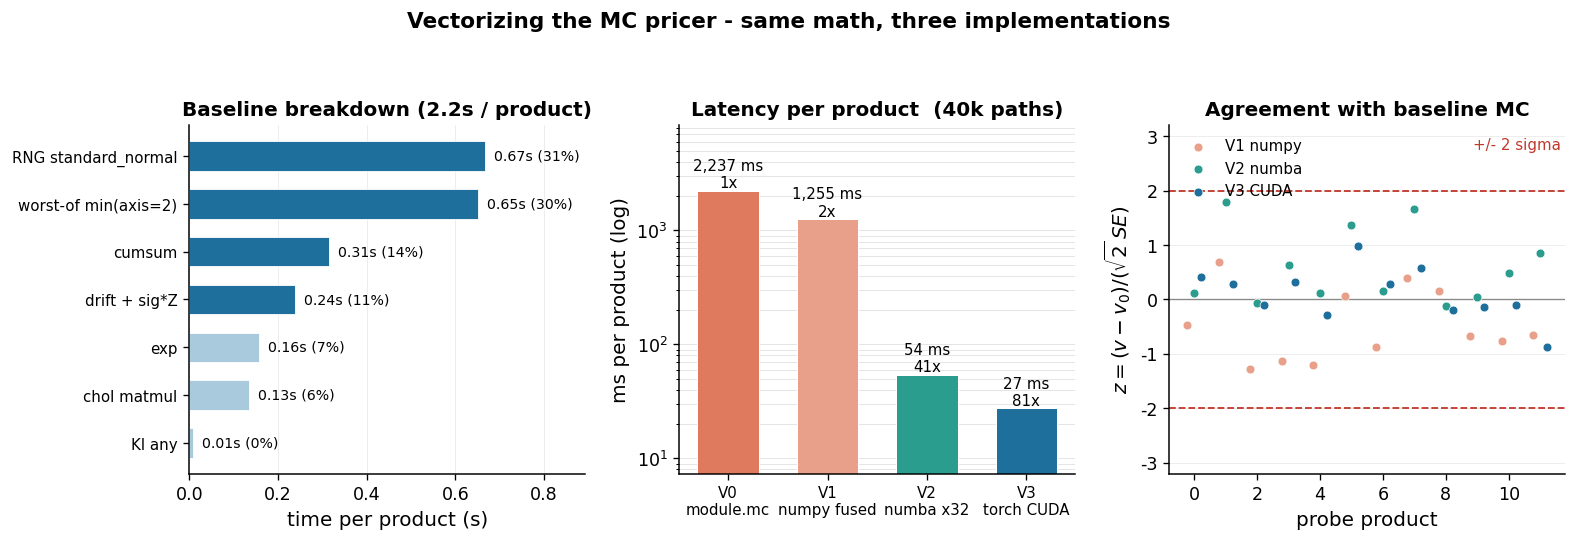

saved -> mc_vectorization.png


In [17]:
# 그림 — 시간분해 · 엔진별 지연시간 · 가격 일치
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.6))

lab = sorted(prof_s, key=lambda k: prof_s[k]); val = [prof_s[k] for k in lab]
yy = np.arange(len(lab))
ax[0].barh(yy, val, color=["#1f6f9c" if v > 0.2 else "#a9c9dd" for v in val],
           edgecolor="white", linewidth=0.5, height=0.62)
ax[0].set_yticks(yy); ax[0].set_yticklabels(lab, fontsize=9)
for i_, v in enumerate(val):
    ax[0].text(v, i_, f"  {v:.2f}s ({v/sum(val)*100:.0f}%)", va="center", fontsize=8.5)
ax[0].set_xlabel("time per product (s)")
ax[0].set_title(f"Baseline breakdown ({sum(val):.1f}s / product)", fontsize=12)
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[0].margins(x=0.34)

names = list(LAT); vals = [LAT[k] * 1e3 for k in names]
short = ["V0\nmodule.mc", "V1\nnumpy fused", "V2\nnumba x32", "V3\ntorch CUDA"][:len(names)]
bb = ax[1].bar(range(len(names)), vals, color=["#e07a5f", "#e8a08a", "#2a9d8f", "#1f6f9c"],
               edgecolor="white", linewidth=0.6, width=0.62)
ax[1].set_yscale("log"); ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels(short, fontsize=9)
ax[1].set_ylabel("ms per product (log)")
ax[1].set_title("Latency per product  (40k paths)", fontsize=12)
for b_, v in zip(bb, vals):
    ax[1].text(b_.get_x() + b_.get_width() / 2, v, f"{v:,.0f} ms\n{base_lat*1e3/v:.0f}x",
               ha="center", va="bottom", fontsize=9)
ax[1].grid(axis="y", which="both", color="#cccccc", lw=0.6, alpha=0.5); ax[1].margins(y=0.30)

for jj, (zc, nm, cc) in enumerate([("z1", "V1 numpy", "#e8a08a"), ("z2", "V2 numba", "#2a9d8f"),
                                   ("z3", "V3 CUDA", "#1f6f9c")]):
    ax[2].scatter(np.arange(len(VER)) + (jj - 1) * 0.22, VER[zc], s=28, color=cc, label=nm,
                  edgecolors="white", linewidths=0.4, zorder=3)
for yb in (-2, 2):
    ax[2].axhline(yb, color="#c0392b", lw=1.1, ls="--")
ax[2].axhline(0, color="#888888", lw=0.8)
ax[2].set_ylim(-3.2, 3.2)
ax[2].text(0.99, 0.965, "+/- 2 sigma", transform=ax[2].transAxes, ha="right", va="top",
           fontsize=9, color="#c0392b")
ax[2].set_xlabel("probe product"); ax[2].set_ylabel(r"$z=(v-v_0)/(\sqrt{2}\,SE)$")
ax[2].set_title("Agreement with baseline MC", fontsize=12)
ax[2].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax[2].legend(fontsize=9, loc="upper left")

fig.suptitle("Vectorizing the MC pricer - same math, three implementations",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("mc_vectorization"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("mc_vectorization").name)

### 6-1. 결론

- **병목은 FLOP가 아니라 난수 생성 + 임시배열 메모리 트래픽**이다. 현재 엔진은 chunk마다 `(2000,1092,3)` float32 배열을
  네 개(Z/incr/R/WP) 만들며, worst-of `min(axis=2)`(길이 3 축 리덕션)만으로 전체의 30%를 쓴다.
- 같은 수학으로도 구현만 바꾸면 **상품당 지연시간이 크게 준다**: V1(numpy 융합) < V2(numba 스트리밍) ≈ V3(CUDA).
  V2/V3가 비슷한 이유는 V3가 여전히 경로를 메모리에 굽기 때문 — 경로별 스트리밍을 GPU 커널로 짜면(numba.cuda/Triton)
  더 내려가지만, 이 환경은 nvvm(cudatoolkit)이 없어 확인하지 못했다.
- **latency와 throughput을 구분해야 정직하다.** 전체 데이터셋 재산출은 이미 [module/mc_shards.py](module/mc_shards.py)의
  프로세스 병렬로 코어 수만큼 먹고 들어간다. 벡터화의 진짜 이득은 **단일 상품 응답시간**(실시간 견적)이고,
  throughput 개선폭은 그보다 작다.
- 그래서 **"81,194x"는 최적화하지 않은 1-스레드 MC 기준**이며, 최적화된 MC 대비 배수는 위 셀이 출력하는
  값으로 읽어야 한다. 그래도 DeepONet이 세 자릿수 배 빠르다는 결론은 바뀌지 않는다 — 오히려 **강한 베이스라인과
  비교했는데도 우위**라는 점에서 주장이 단단해진다.
- 여기서 **쓰지 않은** 카드: antithetic·Sobol QMC·브라운브리지 KI(스텝 축소). 값이 달라져 데이터셋 `mc`와의
  비교 검증이 깨지므로 제외했다. 데이터셋의 98.9%가 3년 만기(N≈1090~1097)라 **상품 배치 GPU 커널**은
  패딩 낭비 없이 바로 적용 가능한 다음 수순이다.

> **후속(이 노트북 이후)**: 여기서 만든 **V3 가 `module/mc_engine.py` 로 정식화**되어 현재 데이터셋의 `mc` 를 만든다. 4구조 58,790건 전량 재산출이 GPU 30분(상품당 29ms)에 끝나고, numpy 기준선과의 일치는 `tests/verify_engine_agreement.py` 가 200상품에서 MAE 8.4원으로 확인한다.
